## Chuẩn bị dữ liệu

In [1]:
%load_ext autoreload
%autoreload 2

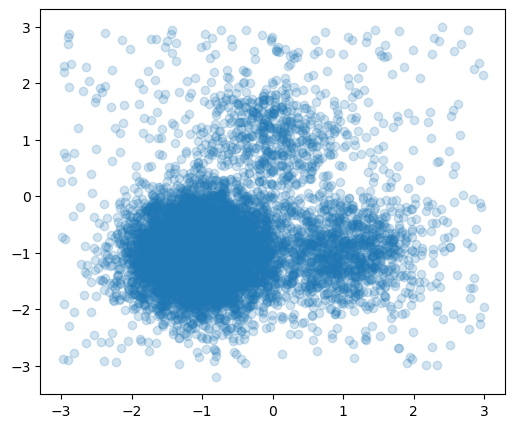

Dữ liệu đã sẵn sàng: (9000, 2)


In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Thêm thư mục cha (thư mục gốc của đồ án) vào sys.path
sys.path.append(os.path.abspath(os.path.join('..')))

# Bây giờ bạn có thể import từ src bình thường
from src.utils import generate_simulated_data

# Khởi tạo dữ liệu
X = generate_simulated_data(random_state=42)

figh, figw = 1, 1
fig, ax = plt.subplots(figh, figw, figsize=(6 * figw, 5))
ax.scatter(X[:, 0], X[:, 1], alpha=0.2)
plt.show()
print(f"Dữ liệu đã sẵn sàng: {X.shape}")

In [3]:
from src.model import hierarchical_kmeans_resampling, kmeans_with_power_s_stable
from src.metrics import calculate_kl_divergence
from sklearn.cluster import KMeans
import pandas as pd # Để lưu kết quả KL cho dễ vẽ biểu đồ
import numpy as np

# Lưu kết quả KL Divergence vào dictionary này
kl_results = {}
# Lưu centroids của các phương pháp để tí nữa vẽ hình (Fig 3a)
all_centroids = {}

# Tính KL cho dữ liệu gốc (Baseline đầu tiên trong Fig 3b)
# Vì KL tính trên centroids, ở đây ta coi 9000 điểm dữ liệu là centroids của chính nó
kl_results['data'] = calculate_kl_divergence(X)

d:\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
d:\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [4]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import pairwise_distances

# --- 1. DBSCAN CHUẨN TÁC GIẢ ---
print("Đang chạy DBSCAN (chuẩn Elbow method)...")
min_points = 5
# Tính khoảng cách k-NN để tìm eps
pw_distance = pairwise_distances(X)
pw_distance = np.sort(pw_distance, axis=1)
nn_dist = pw_distance[:, min_points]
sorted_nn_dist = np.sort(nn_dist)[::-1]

# Epsilon theo đúng elbow của tác giả (vị trí 1000)
eps_elbow = sorted_nn_dist[1000]

db = DBSCAN(eps=eps_elbow, min_samples=min_points).fit(X)

# Tạo danh sách các indices cho từng cụm
db_clusters = [np.where(db.labels_ == i)[0] for i in range(db.labels_.max() + 1)]
# Tính Centroids bằng MEAN của cụm (KHÔNG lấy ngẫu nhiên core points)
db_centroids = np.array([X[db_clusters[i]].mean(axis=0) for i in range(len(db_clusters))])

all_centroids['dbscan'] = db_centroids


# --- 2. AGGLOMERATIVE CHUẨN TÁC GIẢ ---
print("Đang chạy Agglomerative Clustering...")
ac = AgglomerativeClustering(n_clusters=300)
ac.fit(X)

ac_clusters = [np.where(ac.labels_ == i)[0] for i in range(ac.labels_.max() + 1)]
ac_centroids = np.array([X[ac_clusters[i]].mean(axis=0) for i in range(len(ac_clusters))])

all_centroids['agglomerative'] = ac_centroids

# 3. Standard K-means (s=2)
km = KMeans(n_clusters=300, random_state=42).fit(X)
all_centroids['k-means'] = km.cluster_centers_

# Tính KL cho nhóm này
for name in ['dbscan', 'agglomerative', 'k-means']:
    kl_results[name] = calculate_kl_divergence(all_centroids[name])

Đang chạy DBSCAN (chuẩn Elbow method)...
Đang chạy Agglomerative Clustering...


In [5]:
from src.model import kmeans_with_power_s_stable
from src.metrics import calculate_kl_divergence # hoặc compute_KL_divergence tùy tên bạn đặt

print("--- Bắt đầu chạy K-means với power s ---")

for s in [4, 64, 256]:
    name = f'k-means, s={s}'
    print(f"Đang tính toán cho {name}...")
    
    centroids = kmeans_with_power_s_stable(X, k=300, s_target=s, n_iters=20)
    all_centroids[name] = centroids
    
    kl_val = calculate_kl_divergence(centroids, L=3, step=0.02, bandwidth=0.5)
    kl_results[name] = kl_val
    
    print(f"   => Hoàn thành {name}: KL = {kl_val:.4f}")

--- Bắt đầu chạy K-means với power s ---
Đang tính toán cho k-means, s=4...
   => Hoàn thành k-means, s=4: KL = 0.3269
Đang tính toán cho k-means, s=64...
   => Hoàn thành k-means, s=64: KL = 0.1329
Đang tính toán cho k-means, s=256...
   => Hoàn thành k-means, s=256: KL = 0.1157


In [6]:
print("Đang chạy Hierarchical K-means...")

# 1. Ours 2-level (No resampling): k=[1500, 300], r_t=0
all_centroids['ours, 2-level'] = hierarchical_kmeans_resampling(X, [1500, 300], 2, 0, 0, num_init=10)

# 2. Ours 3-level (No resampling): k=[3000, 1000, 300], r_t=0
all_centroids['ours, 3-level'] = hierarchical_kmeans_resampling(X, [3000, 1000, 300], 3, 0, 0, num_init=10)

# 3. Ours 3-level w/ resampling: Dùng đúng r_t = 2 theo tác giả
all_centroids['ours, 3-level w/ resamp.'] = hierarchical_kmeans_resampling(
    X, 
    k_list=[3000, 1000, 300], 
    T=3, 
    m=10, 
    r_t_list=[2, 2, 2], 
    num_init=1
)

# TÍNH TOÀN LẠI KL (Đảm bảo dùng hàm calculate_kl_divergence bản có bandwidth 0.5)
for name in ['ours, 2-level', 'ours, 3-level', 'ours, 3-level w/ resamp.']:
    kl_results[name] = calculate_kl_divergence(all_centroids[name], L=3, step=0.02, bandwidth=0.5)

Đang chạy Hierarchical K-means...


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

In [7]:
lb_vals = []
for _ in range(10):
    rp = np.random.uniform(-3, 3, (300, 2))
    lb_vals.append(calculate_kl_divergence(rp, L=3, step=0.02, bandwidth=0.5))
lower_bound = np.mean(lb_vals)
print(f"Lower bound (random points): KL ≈ {lower_bound:.4f}")

Lower bound (random points): KL ≈ 0.0417


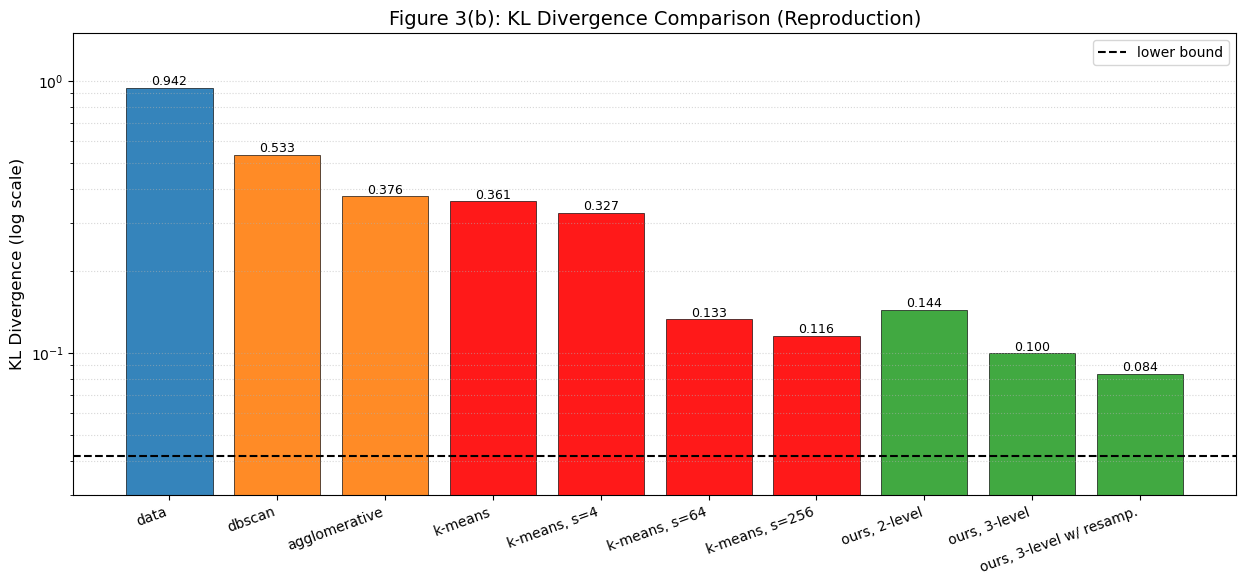

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Sắp xếp dữ liệu theo thứ tự trong bài báo
categories = [
    'data', 'dbscan', 'agglomerative', 'k-means', 
    'k-means, s=4', 'k-means, s=64', 'k-means, s=256', 
    'ours, 2-level', 'ours, 3-level', 'ours, 3-level w/ resamp.'
]

# Lấy giá trị KL, nếu gặp 0 hoặc None thì thay bằng 1e-10 để không lỗi thang Log
values = [kl_results.get(cat, 1e-10) if kl_results.get(cat) is not None else 1e-10 for cat in categories]

# 2. Thiết lập màu sắc chuẩn (Sửa lỗi '#red' -> 'red')
colors = ['tab:blue', 'tab:orange', 'tab:orange', 'red', 'red', 'red', 'red', 'tab:green', 'tab:green', 'tab:green']

plt.figure(figsize=(15, 6))

# Vẽ các cột
bars = plt.bar(categories, values, color=colors, alpha=0.9, edgecolor='black', linewidth=0.5)

# 3. Vẽ đường Lower Bound
# Đảm bảo lower_bound đã được tính ở các cell trước
plt.axhline(y=lower_bound, color='black', linestyle='--', label='lower bound')

# 4. Định dạng biểu đồ
plt.yscale('log') 
plt.ylabel('KL Divergence (log scale)', fontsize=12)
plt.title('Figure 3(b): KL Divergence Comparison (Reproduction)', fontsize=14)
plt.xticks(rotation=20, ha='right')

# Thiết lập giới hạn trục Y để biểu đồ không bị "vỡ" nếu có giá trị quá nhỏ
plt.ylim(bottom=max(1e-3, min(values)*0.5)) 

plt.grid(axis='y', which='both', linestyle=':', alpha=0.5)
plt.legend()

# Hiển thị giá trị trên cột
for bar in bars:
    yval = bar.get_height()
    if yval > 1e-10: # Chỉ ghi số nếu có dữ liệu thật
        plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.3f}', 
                 va='bottom', ha='center', fontsize=9)

# Nếu vẫn lỗi Image size, hãy comment dòng tight_layout() này lại
# plt.tight_layout() 
# 2. Cấu hình trục Y
plt.yscale('log')
plt.ylim(0.03, 1.5) # Ép dải hiển thị từ 0.02 để thấy Lower Bound


plt.show()

C:\Users\QUANG THINH\AppData\Local\Temp\ipykernel_1544\2519593234.py:74: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


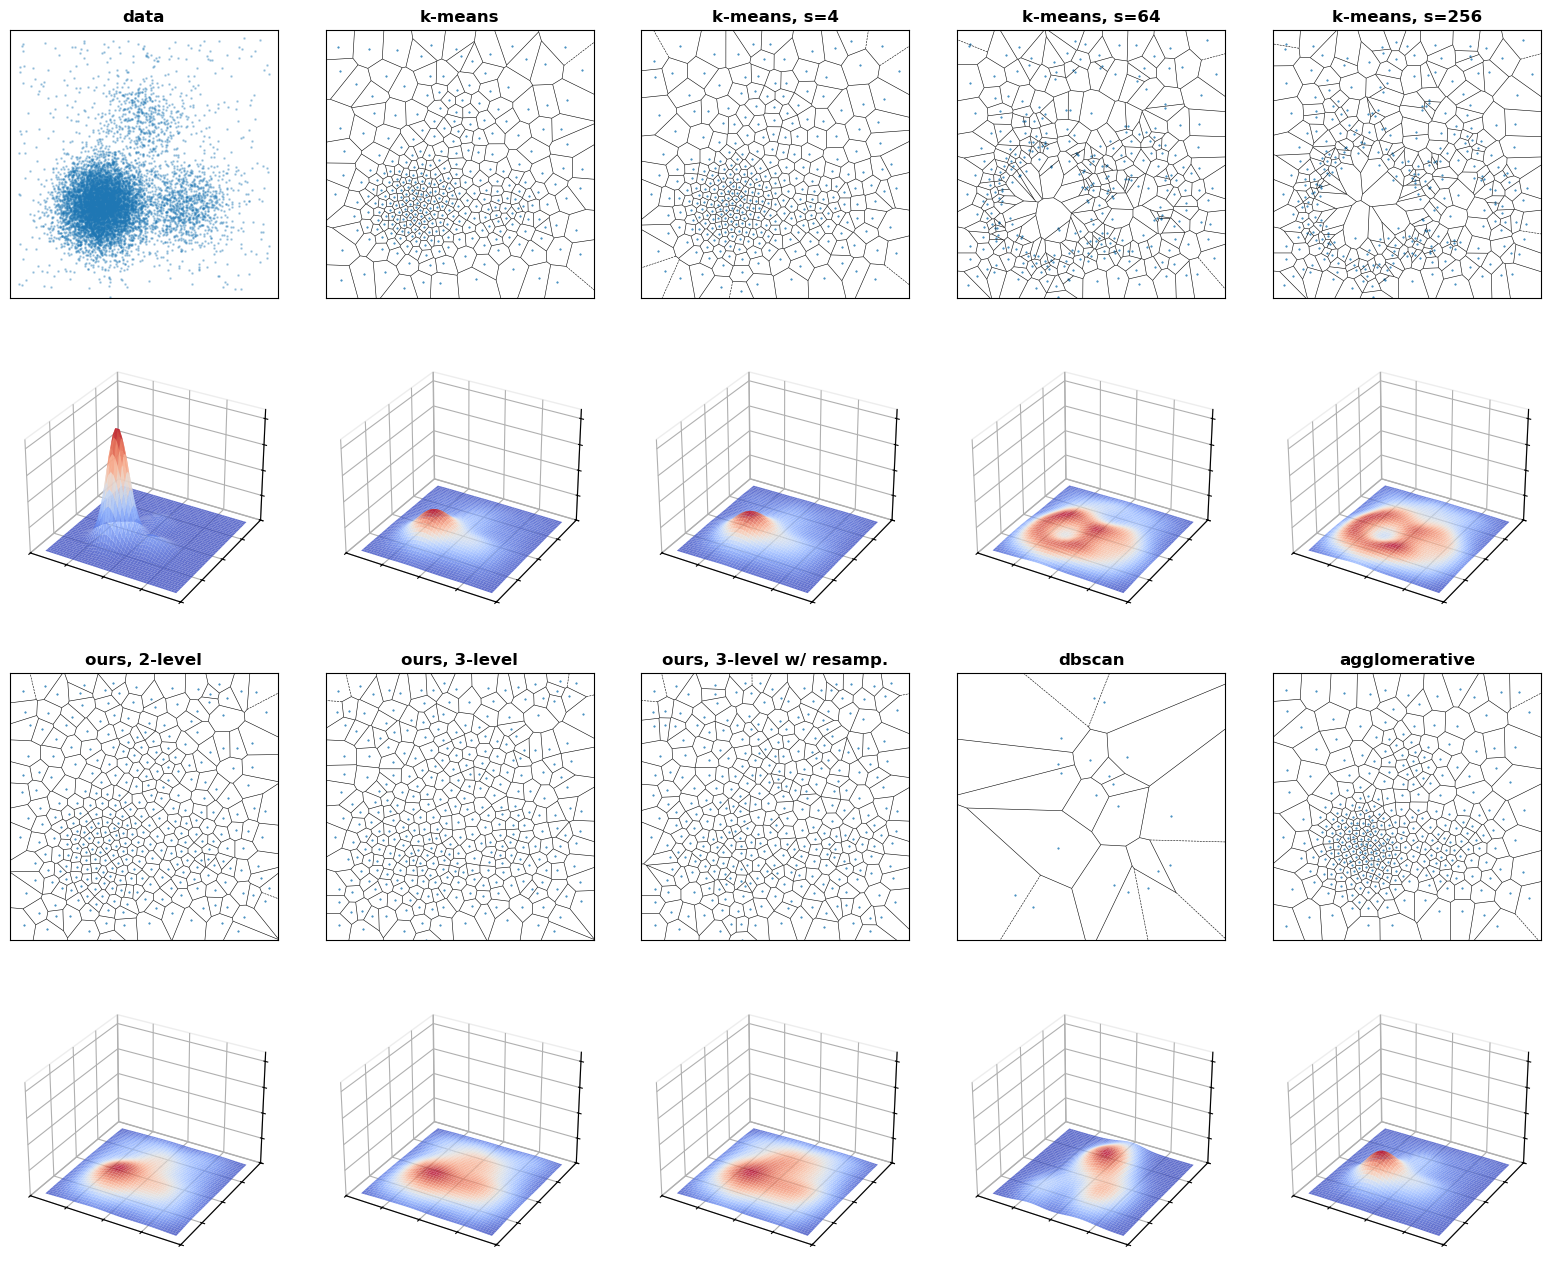

In [9]:
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d
from scipy.stats import gaussian_kde
import numpy as np

def plot_paper_style_fig3a(X, all_centroids):
    # Chia 10 phương pháp thành 2 nhóm, mỗi nhóm 5 phương pháp như trong báo
    group1 = ['data', 'k-means', 'k-means, s=4', 'k-means, s=64', 'k-means, s=256']
    group2 = ['ours, 2-level', 'ours, 3-level', 'ours, 3-level w/ resamp.', 'dbscan', 'agglomerative']
    
    # Thiết lập lưới tọa độ cho KDE
    grid_size = 50
    x_g, y_g = np.mgrid[-3.5:3.5:complex(grid_size), -3.5:3.5:complex(grid_size)]
    pos = np.vstack([x_g.ravel(), y_g.ravel()])
    
    # Tính Z_max để cố định thang đo 3D (giúp thấy rõ sự "làm phẳng")
    z_max = gaussian_kde(X.T)(pos).max()

    # Tạo figure với 4 hàng (2 hàng Voronoi, 2 hàng KDE)
    fig = plt.figure(figsize=(20, 16))
    plt.subplots_adjust(wspace=0.1, hspace=0.2)

    def draw_group(methods, row_start_idx):
        for i, name in enumerate(methods):
            # --- VẼ VORONOI (Hàng 1 và 3) ---
            ax_vor = fig.add_subplot(4, 5, row_start_idx + i + 1)
            if name == 'data':
                ax_vor.scatter(X[:, 0], X[:, 1], s=0.8, alpha=0.3, color='tab:blue')
            else:
                centroids = all_centroids.get(name)
                if centroids is not None:
                    #ax_vor.scatter(X[:, 0], X[:, 1], s=0.5, alpha=0.1, color='gray')
                    vor = Voronoi(centroids)
                    voronoi_plot_2d(vor, ax=ax_vor, show_vertices=False, 
                                    line_colors='black', line_width=0.4, 
                                    point_size=1, point_color='blue')
            
            ax_vor.set_title(name, fontsize=12, fontweight='bold')
            ax_vor.set_xlim(-3.2, 3.2); ax_vor.set_ylim(-3.2, 3.2)
            ax_vor.set_xticks([]); ax_vor.set_yticks([])
            ax_vor.set_aspect('equal')

            # --- VẼ KDE 3D (Hàng 2 và 4) ---
            ax_kde = fig.add_subplot(4, 5, row_start_idx + i + 6, projection='3d')
            source = X if name == 'data' else all_centroids.get(name)
            
            if source is not None:
                kernel = gaussian_kde(source.T)
                z = np.reshape(kernel(pos), x_g.shape)
                # Vẽ surface
                surf = ax_kde.plot_surface(x_g, y_g, z, cmap='coolwarm', 
                                           edgecolor='none', alpha=0.8, antialiased=True)
                
                ax_kde.set_zlim(0, z_max)
                ax_kde.grid(True, linestyle='--', alpha=0.5)
                # Ẩn các con số trên trục để sạch sẽ nhưng giữ lưới
                ax_kde.set_xticklabels([]); ax_kde.set_yticklabels([]); ax_kde.set_zticklabels([])
                # Góc nhìn chuẩn
                ax_kde.view_init(elev=30, azim=-60)
                
                # Làm cho các mặt phẳng (panes) trong suốt hoặc màu xám nhẹ giống báo
                ax_kde.xaxis.pane.set_edgecolor('gainsboro')
                ax_kde.yaxis.pane.set_edgecolor('gainsboro')
                ax_kde.zaxis.pane.set_edgecolor('gainsboro')
                ax_kde.xaxis.pane.fill = False
                ax_kde.yaxis.pane.fill = False
                ax_kde.zaxis.pane.fill = False

    # Vẽ cụm 1 (5 cột đầu) vào 2 hàng đầu
    draw_group(group1, 0)
    # Vẽ cụm 2 (5 cột sau) vào 2 hàng cuối
    draw_group(group2, 10)

    plt.tight_layout()
    plt.show()

# Thực thi
plot_paper_style_fig3a(X, all_centroids)